# 04 – MLP PyTorch
**Owner:** TV3

**Mục tiêu:** MODEL_06, training, validation, early stopping, checkpoint và W&B.


In [ ]:
'''
import sys
sys.path.append("../src")
from preprocessing import load_processed_data
from mlp import train_mlp, predict_mlp
from evaluation import regression_metrics

X_train, X_val, y_train, y_val, X_test = load_processed_data("../data/processed")
model, history, training_time, device = train_mlp(X_train, y_train, X_val, y_val)
val_pred = predict_mlp(model, X_val, device)
print(regression_metrics(y_val, val_pred))
'''


'\nimport sys\nsys.path.append("../src")\nfrom preprocessing import load_processed_data\nfrom mlp import train_mlp, predict_mlp\nfrom evaluation import regression_metrics\n\nX_train, X_val, y_train, y_val, X_test = load_processed_data("../data/processed")\nmodel, history, training_time, device = train_mlp(X_train, y_train, X_val, y_val)\nval_pred = predict_mlp(model, X_val, device)\nprint(regression_metrics(y_val, val_pred))'

## TODO TV3
- Hoàn thiện training loop.
- Early stopping + best checkpoint `experiments/best_mlp.pt`.
- Lưu `experiments/mlp_history.csv`.
- W&B tracking.
- Vẽ train/validation loss.


# MLP PyTorch — House Prices

## 1. Checklist

- [ ] Load dữ liệu processed từ TV1
- [ ] Kiểm tra shape và kiểu dữ liệu
- [ ] Khởi tạo `HousePriceMLP`
- [ ] Train MLP
- [ ] Early Stopping
- [ ] Lưu best checkpoint
- [ ] Lưu training history
- [ ] Theo dõi experiment bằng W&B
- [ ] Đánh giá trên validation set
- [ ] Bàn giao kết quả cho TV4

## 2. Import thư viện

In [2]:
import sys
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Cho phép import các module trong src/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import src.mlp as mlp
importlib.reload(mlp)

from src.mlp import HousePriceMLP, train_mlp, predict_mlp

print("MLP module:", mlp.__file__)

MLP module: d:\MEGA_data\MEGA\HS\Tuan2\lab02_house_price\lab02_house_price\src\mlp.py


## 3. Load dữ liệu

### 3.1. Dữ liệu mẫu để kiểm tra pipeline

> TODO: Thay thế bằng dữ liệu thật từ `data/processed/` sau khi TV1 bàn giao.

In [3]:
processed_dir = PROJECT_ROOT / "data" / "processed"

required_files = [
    "X_train.npy",
    "X_val.npy",
    "y_train.npy",
    "y_val.npy",
    "X_test.npy",
    "preprocessor.joblib",
    "feature_names.json"
]

print("Kiểm tra dữ liệu TV1:")
for filename in required_files:
    path = processed_dir / filename
    print(f"{filename:<25} -> {path.exists()}")

Kiểm tra dữ liệu TV1:
X_train.npy               -> True
X_val.npy                 -> True
y_train.npy               -> True
y_val.npy                 -> True
X_test.npy                -> True
preprocessor.joblib       -> True
feature_names.json        -> True


In [4]:
# Load dữ liệu thật từ TV1
X_train = np.load(processed_dir / "X_train.npy")
X_val = np.load(processed_dir / "X_val.npy")
y_train = np.load(processed_dir / "y_train.npy")
y_val = np.load(processed_dir / "y_val.npy")
X_test = np.load(processed_dir / "X_test.npy")

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("X_test :", X_test.shape)

X_train: (1168, 286)
X_val  : (292, 286)
y_train: (1168,)
y_val  : (292,)
X_test : (1459, 286)


## 4. Kiểm tra dữ liệu

In [5]:
print(" DATA CHECK ")

print("X_train dtype:", X_train.dtype)
print("X_val dtype  :", X_val.dtype)
print("y_train dtype:", y_train.dtype)
print("y_val dtype  :", y_val.dtype)

print("\nMissing values:")
print("X_train NaN:", np.isnan(X_train).sum())
print("X_val NaN  :", np.isnan(X_val).sum())
print("y_train NaN:", np.isnan(y_train).sum())
print("y_val NaN  :", np.isnan(y_val).sum())

print("\nFeature dimension:", X_train.shape[1])

 DATA CHECK 
X_train dtype: float64
X_val dtype  : float64
y_train dtype: int64
y_val dtype  : int64

Missing values:
X_train NaN: 0
X_val NaN  : 0
y_train NaN: 0
y_val NaN  : 0

Feature dimension: 286


In [6]:
print(" TARGET CHECK")

print("y_train:")
print("  min :", y_train.min())
print("  max :", y_train.max())
print("  mean:", y_train.mean())
print("  std :", y_train.std())

print("\ny_val:")
print("  min :", y_val.min())
print("  max :", y_val.max())
print("  mean:", y_val.mean())
print("  std :", y_val.std())

 TARGET CHECK
y_train:
  min : 34900
  max : 745000
  mean: 181441.5419520548
  std : 77230.50161542717

y_val:
  min : 35311
  max : 755000
  mean: 178839.81164383562
  std : 87580.39853293159


In [7]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

print(" LOG TARGET CHECK ")

print("y_train_log:")
print("  min :", y_train_log.min())
print("  max :", y_train_log.max())
print("  mean:", y_train_log.mean())
print("  std :", y_train_log.std())

print("\ny_val_log:")
print("  min :", y_val_log.min())
print("  max :", y_val_log.max())
print("  mean:", y_val_log.mean())
print("  std :", y_val_log.std())

 LOG TARGET CHECK 
y_train_log:
  min : 10.460270761075149
  max : 13.521140839642674
  mean: 12.030658310971573
  std : 0.390438773030285

y_val_log:
  min : 10.471978128496518
  max : 13.534474352733596
  mean: 11.997653730705732
  std : 0.43198494023406786


## 5. Khởi tạo MLP

In [8]:
input_dim = X_train.shape[1]

model = HousePriceMLP(input_dim=input_dim)

print("Input dimension:", input_dim)
print(model)

Input dimension: 286
HousePriceMLP(
  (network): Sequential(
    (0): Linear(in_features=286, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [9]:
x_real = torch.tensor(X_train[:5], dtype=torch.float32)

output_real = model(x_real)

print("Input shape :", x_real.shape)
print("Output shape:", output_real.shape)

Input shape : torch.Size([5, 286])
Output shape: torch.Size([5, 1])


## 6. Training

### 6.1. Huấn luyện MLP ban đầu

In [10]:
model_real, history_real, training_time_real, device_real = train_mlp(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=100,
    batch_size=64,
    lr=1e-3,
    patience=15,
    seed=42
)

print("Device:", device_real)
print("Training time:", training_time_real, "seconds")
print("Epochs actually trained:", len(history_real["train_loss"]))

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ASUS\_netrc.
wandb: Currently logged in as: myang7897 (myang7897-saigon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Early stopping at epoch 31


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,▄█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,31
train_loss,0.71747
val_loss,0.0469


Device: cpu
Training time: 1.1787756000412628 seconds
Epochs actually trained: 31


In [13]:
from src.evaluation import regression_metrics
# Evaluation - Baseline MLP

y_val_pred_baseline = predict_mlp(
    model_real,
    X_val,
    device=device_real
)

baseline_metrics = regression_metrics(
    y_val,
    y_val_pred_baseline
)

print("Baseline MLP Validation Metrics:")

for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.6f}")

Baseline MLP Validation Metrics:
RMSLE: 0.216563
RMSE: 43407.159594
MAE: 28088.300781
R2: 0.754354


### 6.2. Tinh chỉnh siêu tham số
Thử nghiệm một số cấu hình learning rate và batch size để tìm cấu hình có kết quả tốt hơn trên tập validation.

Các siêu tham số khác được giữ cố định để đảm bảo việc so sánh công bằng.

In [ ]:
from itertools import product
from pathlib import Path
import pandas as pd
import numpy as np

# Các giá trị cần Grid Search
learning_rates = [0.0005, 0.001]
batch_sizes = [32, 64]
dropouts = [0.20, 0.30]

grid_results = []

# Tạo thư mục experiments nếu chưa có
experiments_dir = PROJECT_ROOT / "experiments"
experiments_dir.mkdir(parents=True, exist_ok=True)

# Tổng số cấu hình
configs = list(product(learning_rates, batch_sizes, dropouts))

print(f"Total configurations: {len(configs)}")
print("=" * 60)

for run_id, (lr, batch_size, dropout) in enumerate(configs, start=1):

    print(f"\nRun {run_id}/{len(configs)}")
    print(f"Learning rate: {lr}")
    print(f"Batch size:    {batch_size}")
    print(f"Dropout:       {dropout}")

    model, history, training_time, device = train_mlp(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=100,
        batch_size=batch_size,
        lr=lr,
        patience=15,
        seed=42,
        dropout=dropout,
        save_checkpoint=False
    )

    # Lấy validation loss tốt nhất
    best_val_loss = min(history["val_loss"])
    best_epoch = np.argmin(history["val_loss"]) + 1

    grid_results.append({
        "run_id": run_id,
        "learning_rate": lr,
        "batch_size": batch_size,
        "dropout": dropout,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "training_time_seconds": training_time
    })

    print(f"Best val loss: {best_val_loss:.6f}")
    print(f"Best epoch:    {best_epoch}")
    print(f"Training time: {training_time:.4f}s")

# Chuyển thành DataFrame
grid_results_df = pd.DataFrame(grid_results)

# Sắp xếp theo validation loss tăng dần
grid_results_df = grid_results_df.sort_values(
    by="best_val_loss",
    ascending=True
).reset_index(drop=True)

# Lưu kết quả
grid_search_path = experiments_dir / "mlp_grid_search.csv"
grid_results_df.to_csv(grid_search_path, index=False)

print("\n" + "=" * 60)
print("GRID SEARCH COMPLETED")
print("=" * 60)

display(grid_results_df)

print(f"\nSaved to: {grid_search_path}")

Total configurations: 8

Run 1/8
Learning rate: 0.0005
Batch size:    32
Dropout:       0.2


Early stopping at epoch 25


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,25
train_loss,0.64446
val_loss,0.14222


Best val loss: 0.037726
Best epoch:    10
Training time: 1.5306s

Run 2/8
Learning rate: 0.0005
Batch size:    32
Dropout:       0.3


Early stopping at epoch 31


...

Early stopping at epoch 26


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,▃█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁
epoch,26
train_loss,1.19521
val_loss,0.08564


Best val loss: 0.049894
Best epoch:    11
Training time: 0.9482s

GRID SEARCH COMPLETED


,run_id,learning_rate,batch_size,dropout,best_val_loss,best_epoch,training_time_seconds
0,3,0.0005,64,0.2,0.034876,25,1.429762
1,1,0.0005,32,0.2,0.037726,10,1.530609
2,4,0.0005,64,0.3,0.039091,30,1.648051
3,7,0.0010,64,0.2,0.041782,16,1.151604
4,2,0.0005,32,0.3,0.043682,16,1.786667
5,8,0.0010,64,0.3,0.049894,11,0.948225
6,5,0.0010,32,0.2,0.050373,27,2.454894
7,6,0.0010,32,0.3,0.065331,11,1.592904



Saved to: d:\MEGA_data\MEGA\HS\Tuan2\lab02_house_price\lab02_house_price\experiments\mlp_grid_search.csv


### 6.3. Huấn luyện MLP với cấu hình tốt nhất

In [ ]:
# Tìm cấu hình tốt nhất dựa trên validation loss
best_row = grid_results_df.loc[
    grid_results_df["best_val_loss"].idxmin()
]

best_lr = float(best_row["learning_rate"])
best_batch_size = int(best_row["batch_size"])
best_dropout = float(best_row["dropout"])

print(" Best Hyperparameters ")
print(f"Learning rate: {best_lr}")
print(f"Batch size:    {best_batch_size}")
print(f"Dropout:       {best_dropout}")
print(f"Best val loss: {best_row['best_val_loss']:.6f}")

 Best Hyperparameters 
Learning rate: 0.0005
Batch size:    64
Dropout:       0.2
Best val loss: 0.034876


In [ ]:
final_model, final_history, final_training_time, final_device = train_mlp(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    batch_size=best_batch_size,
    lr=best_lr,
    patience=15,
    seed=42,
    dropout=best_dropout,
    save_checkpoint=True
)

print(" Final MLP ")
print(f"Learning rate: {best_lr}")
print(f"Batch size:    {best_batch_size}")
print(f"Dropout:       {best_dropout}")
print(f"Training time: {final_training_time:.4f}s")
print(f"Device:        {final_device}")

Early stopping at epoch 40


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
train_loss,0.66515
val_loss,0.05929


 Final MLP 
Learning rate: 0.0005
Batch size:    64
Dropout:       0.2
Training time: 1.5030s
Device:        cpu


## 7. Training History

In [ ]:
history_path = PROJECT_ROOT / "experiments" / "mlp_history.csv"

final_history_df = pd.read_csv(history_path)

print(final_history_df.head())

print("\nSố epoch:", len(final_history_df))

best_idx = final_history_df["val_loss"].idxmin()

print("\nBest epoch:", int(final_history_df.loc[best_idx, "epoch"]))

print("Best train loss:", final_history_df.loc[best_idx, "train_loss"])

print("Best val loss:", final_history_df.loc[best_idx, "val_loss"])

   epoch  train_loss    val_loss
0      1  133.795393  105.082848
1      2   46.752654    7.816539
2      3    5.451430    2.684621
3      4    1.597232    0.227738
4      5    0.919113    0.071282

Số epoch: 40

Best epoch: 25
Best train loss: 0.7169039992436971
Best val loss: 0.0348757654428482


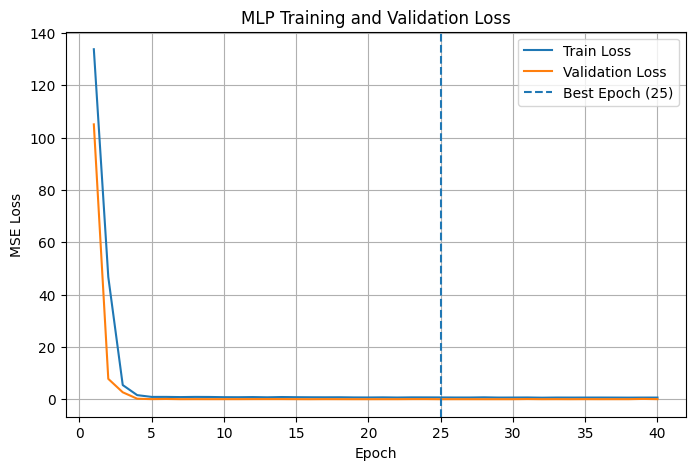

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history_df["epoch"],
    final_history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    final_history_df["epoch"],
    final_history_df["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    x=int(final_history_df.loc[best_idx, "epoch"]),
    linestyle="--",
    label=f"Best Epoch ({int(final_history_df.loc[best_idx, 'epoch'])})"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

## 8. W&B Tracking

Theo dõi quá trình huấn luyện với W&B.
W&B (Weights & Biases) được sử dụng để theo dõi quá trình huấn luyện mô hình MLP.

Các thông tin được ghi nhận gồm:
- Learning rate
- Batch size
- Số epoch
- Patience của Early Stopping
- Kiến trúc các lớp ẩn
- Dropout
- Optimizer
- Loss
- Training loss theo epoch
- Validation loss theo epoch

Kết quả huấn luyện được đồng bộ lên project `lab02-house-price` trên W&B. Xem tại đường dẫn mục trainning (mục 6).

## 9. Evaluation

In [ ]:
y_val_pred = predict_mlp(
    final_model,
    X_val,
    device=final_device
)

print("Prediction shape:", y_val_pred.shape)

print("Actual shape:", y_val.shape)

print("\nFirst 5 predictions:")

print(y_val_pred[:5])

print("\nFirst 5 actual values:")

print(y_val[:5])

Prediction shape: (292,)
Actual shape: (292,)

First 5 predictions:
[164099.92 331566.6  125464.74 192453.3  296173.84]

First 5 actual values:
[154500 325000 115000 159000 315500]


In [ ]:
from src.evaluation import regression_metrics

mlp_metrics = regression_metrics(
    y_val,
    y_val_pred
)

print("MLP Validation Metrics:")
for metric, value in mlp_metrics.items():
    print(f"{metric}: {value:.6f}")

MLP Validation Metrics:
RMSLE: 0.186751
RMSE: 34670.425437
MAE: 24773.132812
R2: 0.843287


In [ ]:
from pathlib import Path

import pandas as pd

results_dir = PROJECT_ROOT / "results"

results_dir.mkdir(parents=True, exist_ok=True)

result_row = pd.DataFrame([{
    "model": "MLP",

    "RMSLE": mlp_metrics["RMSLE"],
    "RMSE": mlp_metrics["RMSE"],
    "MAE": mlp_metrics["MAE"],
    "R2": mlp_metrics["R2"],

    "training_time_seconds": final_training_time,

    "kaggle_score": None,

    "notes": "PyTorch MLP with log1p target, early stopping"
}])

results_path = results_dir / "model_results.csv"

result_row.to_csv(results_path, index=False)

print("Saved:", results_path)
print(result_row)

Saved: d:\MEGA_data\MEGA\HS\Tuan2\lab02_house_price\lab02_house_price\results\model_results.csv
  model     RMSLE          RMSE           MAE        R2  \
0   MLP  0.186751  34670.425437  24773.132812  0.843287   

   training_time_seconds kaggle_score  \
0               1.503001         None   

                                           notes  
0  PyTorch MLP with log1p target, early stopping  


In [ ]:
results_path = PROJECT_ROOT / "results" / "model_results.csv"

check_results = pd.read_csv(results_path)

print(check_results)

  model     RMSLE          RMSE           MAE        R2  \
0   MLP  0.186751  34670.425437  24773.132812  0.843287   

   training_time_seconds  kaggle_score  \
0               1.503001           NaN   

                                           notes  
0  PyTorch MLP with log1p target, early stopping  


In [ ]:
# Check file có ghi model ko
checkpoint_path = PROJECT_ROOT / "experiments" / "best_mlp.pt"

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu"
)

print("Checkpoint type:", type(checkpoint))
print("Number of parameters:", len(checkpoint))

print("\nFirst 5 parameter names:")
for name in list(checkpoint.keys())[:5]:
    print(name, checkpoint[name].shape)

Checkpoint type: <class 'collections.OrderedDict'>
Number of parameters: 8

First 5 parameter names:
network.0.weight torch.Size([256, 286])
network.0.bias torch.Size([256])
network.3.weight torch.Size([128, 256])
network.3.bias torch.Size([128])
network.6.weight torch.Size([64, 128])


In [ ]:
# Load model từ checkpoint
reloaded_model = HousePriceMLP(
    input_dim=X_train.shape[1]
)

reloaded_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location="cpu"
    )
)

reloaded_model.eval()

reloaded_pred = predict_mlp(
    reloaded_model,
    X_val,
    device="cpu"
)

print("Reloaded prediction shape:", reloaded_pred.shape)
print("First 5 reloaded predictions:", reloaded_pred[:5])

Reloaded prediction shape: (292,)
First 5 reloaded predictions: [164099.92 331566.6  125464.74 192453.3  296173.84]


In [ ]:
import json

best_final_epoch = int(
    np.argmin(final_history["val_loss"]) + 1
)

config = {
    "model": "HousePriceMLP",

    "input_dim": int(X_train.shape[1]),

    "hidden_dims": [256, 128, 64],

    "dropout": best_dropout,

    "loss": "MSELoss",

    "optimizer": "Adam",

    "learning_rate": best_lr,

    "batch_size": best_batch_size,

    "max_epochs": 100,

    "patience": 15,

    "seed": 42,

    "target_transform": "log1p",

    "prediction_transform": "expm1",

    "device": str(final_device),

    "best_epoch": best_final_epoch,

    "training_time_seconds": float(final_training_time)
}

config_path = PROJECT_ROOT / "experiments" / "mlp_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4, ensure_ascii=False)

print("Saved:", config_path)

Saved: d:\MEGA_data\MEGA\HS\Tuan2\lab02_house_price\lab02_house_price\experiments\mlp_config.json


In [ ]:
config_check = PROJECT_ROOT / "experiments" / "mlp_config.json"

print("File exists:", config_check.exists())

with open(config_check, "r", encoding="utf-8") as f:
    print(f.read())

File exists: True
{
    "model": "HousePriceMLP",
    "input_dim": 286,
    "hidden_dims": [
        256,
        128,
        64
    ],
    "dropout": 0.2,
    "loss": "MSELoss",
    "optimizer": "Adam",
    "learning_rate": 0.0005,
    "batch_size": 64,
    "max_epochs": 100,
    "patience": 15,
    "seed": 42,
    "target_transform": "log1p",
    "prediction_transform": "expm1",
    "device": "cpu",
    "best_epoch": 25,
    "training_time_seconds": 1.5030005000298843
}


## 10. Kết luận

Mô hình MLP đã được xây dựng và huấn luyện bằng PyTorch cho bài toán dự đoán giá nhà.

### MLP ban đầu

- Kiến trúc: `286 → 256 → 128 → 64 → 1`.
- Sử dụng ReLU và Dropout.
- Biến mục tiêu `SalePrice` được biến đổi bằng `log1p` trong quá trình huấn luyện và chuyển ngược bằng `expm1` khi dự đoán.
- Sử dụng Adam, learning rate `0.001`, batch size `64` và Early Stopping.
- Kết quả trên tập validation:
  - RMSLE: `0.216563`
  - RMSE: `43407.159594`
  - MAE: `28088.300781`
  - R2: `0.754354`

### MLP sau tinh chỉnh siêu tham số

Grid Search được thực hiện trên các tham số `learning rate`, `batch size` và `dropout`, với tổng cộng 8 cấu hình. Các cấu hình được đánh giá trên tập validation.

Cấu hình tốt nhất được lựa chọn dựa trên validation loss:

- Learning rate: `0.0005`
- Batch size: `64`
- Dropout: `0.20`

Final MLP được huấn luyện lại với cấu hình tốt nhất và sử dụng Early Stopping. Kết quả validation của Final MLP được sử dụng để so sánh với mô hình MLP ban đầu và các mô hình hồi quy khác.

Các kết quả thực nghiệm được lưu tại:

- `experiments/mlp_grid_search.csv`: kết quả của 8 cấu hình Grid Search.
- `experiments/best_mlp.pt`: checkpoint của Final MLP.
- `experiments/mlp_history.csv`: lịch sử huấn luyện của Final MLP.
- `experiments/mlp_config.json`: cấu hình của Final MLP.
- `results/model_results.csv`: metrics của mô hình.

W&B được sử dụng để theo dõi quá trình huấn luyện và các thông số thực nghiệm.